### Import Libs

In [1]:
!pip -q install torch sentencepiece records babel tqdm tabulate

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.6 MB/s eta 0:00:00


In [31]:
import json
from pathlib import Path
import sentencepiece as spm
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import time
from datetime import timedelta
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
from torch.optim.lr_scheduler import LambdaLR


### Download Data from GitHub

In [3]:
!git clone https://github.com/salesforce/WikiSQL

Cloning into 'WikiSQL'...
remote: Enumerating objects: 389, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 389 (delta 186), reused 154 (delta 154), pack-reused 194 (from 1)
Receiving objects: 100% (389/389), 50.72 MiB | 24.83 MiB/s, done.
Resolving deltas: 100% (213/213), done.


In [ ]:
%cd WikiSQL
!ls

/content/WikiSQL
annotate.py  CONTRIBUTING-ARCHIVED.md  lib	  requirements.txt
CODEOWNERS   data.tar.bz2	       LICENSE	  test
collection   evaluate.py	       README.md  version.txt


In [5]:
!tar xvjf data.tar.bz2
%cd ..

data/
data/train.jsonl
data/test.tables.jsonl
data/test.db
data/dev.tables.jsonl
data/dev.db
data/test.jsonl
data/train.tables.jsonl
data/train.db
data/dev.jsonl
/content


### Load & Preprocess

In [6]:
DATA_DIR = Path("WikiSQL/data")
AGG_OPS = ["", "MAX", "MIN", "COUNT", "SUM", "AVG"]
COND_OPS = ["=", ">", "<"]
MAX_COLS = 64  # column tokens <c0> ... <c63>


def load_split(split):
    """Return (examples, tables) for 'train', 'dev' or 'test'."""
    tables = {}

    with open(DATA_DIR / f"{split}.tables.jsonl", encoding="utf-8") as f:
        for line in f:
            t = json.loads(line)
            tables[t["id"]] = t

    with open(DATA_DIR / f"{split}.jsonl", encoding="utf-8") as f:
        examples = [json.loads(line) for line in f]

    return examples, tables


def encode_source(question, header):
    """question <sep> <c0> col name <c1> col name ..."""
    cols = " ".join(
        f"<c{i}> {name}" for i, name in enumerate(header)
    )
    return f"{question.strip()} <sep> {cols}".lower()


def encode_target(sql):
    """{'sel','agg','conds'} -> 'select count <c3> where <c1> = kim manners'"""
    out = ["select"]

    if sql["agg"]:
        out.append(AGG_OPS[sql["agg"]].lower())

    out.append(f"<c{sql['sel']}>")

    for i, (col, op, val) in enumerate(sql["conds"]):
        out += [
            "where" if i == 0 else "and",
            f"<c{col}>",
            COND_OPS[op],
            str(val)
        ]

    return " ".join(out).lower()


def build_pairs(split):
    examples, tables = load_split(split)
    pairs = []

    for ex in examples:
        header = tables[ex["table_id"]]["header"]

        pairs.append({
            "table_id": ex["table_id"],
            "src": encode_source(ex["question"], header),
            "tgt": encode_target(ex["sql"]),
        })

    return pairs

In [7]:
for split in ["train", "dev", "test"]:
        pairs = build_pairs(split)

        with open(
            f"{split}_pairs.jsonl", "w", encoding="utf-8"
        ) as f:
            for p in pairs:
                f.write(json.dumps(p, ensure_ascii=False) + "\n")

        print(f"{split}: {len(pairs)} pairs")
        print(pairs[0]["src"])
        print(pairs[0]["tgt"])

train: 56355 pairs
tell me what the notes are for south australia <sep> <c0> state/territory <c1> text/background colour <c2> format <c3> current slogan <c4> current series <c5> notes
select <c5> where <c3> = south australia
dev: 8421 pairs
what position does the player who played for butler cc (ks) play? <sep> <c0> player <c1> no. <c2> nationality <c3> position <c4> years in toronto <c5> school/club team
select <c3> where <c5> = butler cc (ks)
test: 15878 pairs
what is terrence ross' nationality <sep> <c0> player <c1> no. <c2> nationality <c3> position <c4> years in toronto <c5> school/club team
select <c2> where <c0> = terrence ross


### Tokenizer

In [ ]:
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3
SPECIAL = ["<sep>"] + [f"<c{i}>" for i in range(MAX_COLS)]


def read_pairs(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f]


def train_tokenizer(train_path="train_pairs.jsonl", vocab_size=8000):
    pairs = read_pairs(train_path)

    with open("spm_corpus.txt", "w", encoding="utf-8") as f:
        for p in pairs:  # ONE shared vocabulary for
            f.write(p["src"] + "\n")  # source and target, as in
            f.write(p["tgt"] + "\n")  # the original Transformer

    spm.SentencePieceTrainer.train(
        input="spm_corpus.txt",
        model_prefix="sql_sp",
        vocab_size=vocab_size,
        model_type="bpe",
        character_coverage=1.0,
        user_defined_symbols=SPECIAL,  # never split <sep>, <c0>, ...
        pad_id=PAD_ID,
        unk_id=UNK_ID,
        bos_id=BOS_ID,
        eos_id=EOS_ID,
    )

    return spm.SentencePieceProcessor(model_file="sql_sp.model")


In [9]:
sp = train_tokenizer()
p = read_pairs("dev_pairs.jsonl")[0]

print(sp.encode(p["src"], out_type=str))
print(sp.encode(p["tgt"], out_type=str))
print(sp.decode(sp.encode(p["tgt"])) == p["tgt"])

['▁what', '▁position', '▁does', '▁the', '▁player', '▁who', '▁played', '▁for', '▁but', 'ler', '▁cc', '▁(', 'ks', ')', '▁play', '?', '▁', '<sep>', '▁', '<c0>', '▁player', '▁', '<c1>', '▁no', '.', '▁', '<c2>', '▁nationality', '▁', '<c3>', '▁position', '▁', '<c4>', '▁years', '▁in', '▁toronto', '▁', '<c5>', '▁school', '/', 'club', '▁team']
['▁select', '▁', '<c3>', '▁where', '▁', '<c5>', '▁=', '▁but', 'ler', '▁cc', '▁(', 'ks', ')']
True


### Dataloaders

In [10]:
class SQLDataset(Dataset):
    """
    Each item: (source ids, target ids). Target = <s> ... </s>.
    train=True drops over-long pairs.
    train=False keeps EVERY row in file order (needed for evaluation).
    """

    def __init__(self, path, sp, train=True, max_src=160, max_tgt=64):
        self.items, skipped = [], 0

        for p in read_pairs(path):
            src = sp.encode(p["src"]) + [EOS_ID]
            tgt = [BOS_ID] + sp.encode(p["tgt"]) + [EOS_ID]

            if train and (len(src) > max_src or len(tgt) > max_tgt):
                skipped += 1
                continue

            self.items.append((src, tgt))

        print(f"{path}: kept {len(self.items)}, skipped {skipped}")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]


def collate(batch):
    srcs, tgts = zip(*batch)

    S, T = max(map(len, srcs)), max(map(len, tgts))

    src = torch.full(
        (len(batch), S),
        PAD_ID,
        dtype=torch.long
    )

    tgt = torch.full(
        (len(batch), T),
        PAD_ID,
        dtype=torch.long
    )

    for i, (s, t) in enumerate(zip(srcs, tgts)):
        src[i, :len(s)] = torch.tensor(s)
        tgt[i, :len(t)] = torch.tensor(t)


    return src, tgt  # (B, S), (B, T)


def make_loader(path, sp, train, batch_size=64):
    return DataLoader(
        SQLDataset(path, sp, train=train),
        batch_size=batch_size,
        shuffle=train,
        collate_fn=collate
    )

### Embeddings & Positional encoding

In [ ]:
class TokenEmbedding(nn.Module):
    """
    Section 3.4: embeddings are multiplied by sqrt(d_model).
    One instance is shared by the encoder, the decoder and
    (optionally) the final output projection.
    """

    def __init__(self, vocab_size, d_model, pad_id=0):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.scale = math.sqrt(d_model)

    def forward(self, ids):  # (Batch size, seq lenght) -> (Batch size, seq lenght, d_model)
        return self.emb(ids) * self.scale


class PositionalEncoding(nn.Module):
    """
    Section 3.5: fixed sinusoidal encodings.
    PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """

    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pos = torch.arange(max_len).unsqueeze(1)  # (L, 1)

        div = torch.exp(
            torch.arange(0, d_model, 2)
            * (-math.log(10000.0) / d_model)
        )  # (d/2,)

        pe = torch.zeros(max_len, d_model)

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        self.register_buffer(
            "pe",
            pe.unsqueeze(0)
        )  # (1, L, d)

    def forward(self, x):  # x: (B, L, d_model)
        return self.dropout(
            x + self.pe[:, :x.size(1)]
        )


class InputLayer(nn.Module):
    """
    token ids -> scaled embedding + positional encoding -> dropout
    """

    def __init__(
        self,
        token_emb,
        d_model,
        max_len=512,
        dropout=0.1
    ):
        super().__init__()

        self.tok = token_emb
        self.pos = PositionalEncoding(
            d_model,
            max_len,
            dropout
        )

    def forward(self, ids):
        return self.pos(self.tok(ids))

### Check Starter Codes

In [12]:
sp = spm.SentencePieceProcessor(model_file="sql_sp.model")

train_dl = make_loader("train_pairs.jsonl", sp, train=True)
dev_dl = make_loader("dev_pairs.jsonl", sp, train=False)


src, tgt = next(iter(train_dl))

print("src", tuple(src.shape), "tgt", tuple(tgt.shape))


d_model = 256

shared = TokenEmbedding(
    sp.get_piece_size(),
    d_model,
    PAD_ID
)

enc_in = InputLayer(shared, d_model)  # encoder input
dec_in = InputLayer(shared, d_model)  # decoder input (same weights)


x = enc_in(src)  # (B, S, 256) -> goes into YOUR encoder
y = dec_in(tgt[:, :-1])  # (B, T-1, 256) -> goes into YOUR decoder

print(
    "encoder input",
    tuple(x.shape),
    "decoder input",
    tuple(y.shape)
)

train_pairs.jsonl: kept 56336, skipped 19
dev_pairs.jsonl: kept 8421, skipped 0
src (64, 102) tgt (64, 30)
encoder input (64, 102, 256) decoder input (64, 29, 256)


### Achitecture
Layers:
* Multi-head Attention
* Norm & Skip connection
* FFN

Encoder:
* Encoder_layer (self-attention → add & norm → FFN → add & norm)
* Encoder (N layers stacked)

Decoder:
* Decoder_layer (masked self-attention →add & norm →cross-attention over the encoder output → add & norm → FFN → add & norm)
* Decoder (N layers Stacked)

In [13]:
import math
import torch
import torch.nn as nn


class MultiHeadAttention(nn.Module):
    """multi-head attention mechanism
    """

    def __init__(self, d_model: int, h: int, dropout: float=0.1):
        """initializer of multi-head attention mechanism

        Args:
            d_model (int): model hidden dimension
            h (int): number of heads
            dropout (float, optional): dropout to be applied on attention scores. Defaults to 0.1.
        """
        super().__init__()
        
        self.d_model = d_model # embedding dim
        self.h = h # no. heads
        self.d_k = d_model // h # dim of each head
        
        self.dropout = nn.Dropout(dropout)
        
        self.w_q = nn.Linear(d_model, d_model) # query
        self.w_k = nn.Linear(d_model, d_model) # key
        self.w_v = nn.Linear(d_model, d_model) # value
        
        self.w_o = nn.Linear(d_model, d_model) # output

    def forward(self, query, key, value, mask=None):
        """forward pass for the multi-head attention mechanism

        Args:
            query (tensor): query tensor of shape (batch, seq_len, d_model)
            key (tensor): key tensor of shape (batch, seq_len, d_model)
            value (tensor): value tensor of shape (batch, seq_len, d_model)
            mask (tensor): mask tensor of shape (batch, 1, 1, seq_len) or (batch, 1, seq_len, seq_len)

        Returns:
            tensor: output tensor of shape (batch, seq_len, d_model)
        """
        if mask is not None and mask.device != query.device:
            mask = mask.to(query.device)

        Q = self.w_q(query) # (batch, seq_len, d_model) @ (d_model, d_model) -> (batch, seq_len, d_model)
        K = self.w_k(key) # //
        V = self.w_v(value) # //
        
        q = Q.view(Q.size(0), Q.size(1), self.h, self.d_k) # (batch , seq_len, h, d_k)
        k = K.view(K.size(0), K.size(1), self.h, self.d_k) # //
        v = V.view(V.size(0), V.size(1), self.h, self.d_k) # //
        
        q = q.transpose(1, 2) # (batch, h, seq_len, d_k)
        k = k.transpose(1, 2) # //
        v = v.transpose(1, 2) # //
        
        score, _ = MultiHeadAttention.attention(q, k, v, mask, self.dropout) # (batch, h, seq_len, d_k)
        score = score.transpose(1, 2).contiguous().view(score.size(0), -1, self.d_model) # (batch, seq_len, d_model)
        
        return self.w_o(score) # (batch, seq_len, d_model) @ (d_model, d_model) -> (batch, seq_len, d_model)

    @staticmethod
    def attention(q, k, v, mask, dropout: nn.Dropout):
        """applies multi-head attention to the input tensors.
        
        Args:
            q (tensor): query tensor of shape (batch, h, seq_len, d_k)
            k (tensor): key tensor of shape (batch, h, seq_len, d_k)
            v (tensor): value tensor of shape (batch, h, seq_len, d_k)
            mask (tensor): mask tensor of shape (batch, 1, 1, seq_len) or (batch, 1, seq_len, seq_len)
            dropout (tensor, optional): dropout layer to be applied on attention scores. Defaults to None.

        Returns:
            tensor: output tensor of shape (batch, h, seq_len, d_k) and attention scores of shape (batch, h, seq_len, seq_len)
        """
        d_k = q.size(-1)

        att = q @ k.transpose(-2, -1) / math.sqrt(d_k) # (batch, h ,seq_len, d_k) @ (batch, h, d_k, seq_len) -> (batch, h, seq_len, seq_len)

        if mask is not None:
            att = att.masked_fill(mask == 0, float("-inf"))
        
        score = torch.softmax(att, dim=-1)

        if dropout is not None:
            score = dropout(score)

        # score @ v (batch, h, seq_len, seq_len) @ (batch, h, seq_len, d_k) -> (batch, h, seq_len, d_k)
        return score @ v, score

In [14]:
class AddNorm(nn.Module):
    """x -> sublayer(x) -> dropout -> add(x) -> norm
    """

    def __init__(self, d_model: int, dropout: float= 0.1):
        """initializer of add and norm component of transformer

        Args:
            d_model (int): model hidden dimention
            dropout (float, optional): dropout to be applied on sublayer output. Defaults to 0.1.
        """
        super().__init__()

        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)
        
    def forward(self, x, sublayer):
        """forward pass of the add & norm layer

        Args:
            x (tensor): input tensor of shape (batch, seq_len, d_model)
            sublayer (function): function to be applied on x

        Returns:
            tensor: output normalized tensor of shape (batch, seq_len, d_model)
        """
        added = x + self.dropout(sublayer(x)) # (batch, seq_len, d_model) + (batch, seq_len, d_model) -> (batch, seq_len, d_model)
        output = self.norm(added)
        
        return output # (batch, seq_len, d_model)


class FeedForward(nn.Module):
    """x -> linear(d_ff) -> relu -> dropout(optional) -> linear(d_model)
    """

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        """initialzier of the feed forward module

        Args:
            d_model (int): model hidden dimention
            d_ff (int, optional): feed forward intermediate hidden dimention
            dropout (float, optional): dropout to be applied after activation. Defaults to 0.1.
        """
        super().__init__()
        
        self.linear1 = nn.Linear(d_model, d_ff)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)
        
    def forward(self, x):
        """forward pass of the feed forward network

        Args:
            x (tensor): input tensor of shape (batch, seq_len, d_model)

        Returns:
            tensor: output tensor of shape (batch, seq_len, d_model)
        """
        x = self.linear1(x) # (batch, seq_len, d_model) @ (d_model, d_ff) -> (batch, seq_len, d_ff)
        x = self.relu(x) # (batch, seq_len, d_ff)
        x = self.dropout(x)
        output = self.linear2(x) # (batch, seq_len, d_ff) @ (d_ff, d_model) -> (batch, seq_len, d_model)
        
        return output

In [15]:
class EncoderLayer(nn.Module):
    """x -> multi-head attention -> add & norm -> feed forward -> add & norm
    """

    def __init__(self, multi_head_attention: MultiHeadAttention, feed_forward_network: FeedForward, d_model: int, dropout: float=0.1):
        """initializer for encoder layer module

        Args:
            multi_head_attention (MultiHeadAttention): multi-head attention module
            feed_forward_network (FeedForward): feed forward network module
            d_model (int): model hidden dimention
            dropout (float, optional): dropout to be applied on encoder layer. Defaults to 0.1.
        """
        super().__init__()

        self.mha = multi_head_attention
        self.ffn = feed_forward_network
        self.add_norms = nn.ModuleList([AddNorm(d_model, dropout) for _ in range(2)])
        
    def forward(self, x, src_mask=None):
        """forward pass for encoder layer module

        Args:
            x (tensor): input tensor of shape (batch, s_seq_len, d_model)
            seq_mask (tensor): sequence mask tensor of shape (batch, 1, 1, s_seq_len)

        Returns:
            tensor: output tensor of shape (batch, s_seq_len, d_model)
        """
        if src_mask is not None and src_mask.device != x.device:
            src_mask = src_mask.to(x.device)

        x = self.add_norms[0](x, lambda x: self.mha(x, x, x, src_mask)) # (batch, s_seq_len, d_model)
        output = self.add_norms[1](x, self.ffn) # (batch, s_seq_len, d_model)
        
        return output

In [16]:
class Encoder(nn.Module):
    """x -> N * encoder layer -> layer norm
    """

    def __init__(self, d_model: int, layers: nn.ModuleList):
        """initializer for encoder module

        Args:
            d_model (int): model hidden dimention
            layers (nn.ModuleList): list of encoder layers
        """
        super().__init__()

        self.layers = layers
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, src_mask=None):
        """forward pass for encoder module

        Args:
            x (tensor): input tensor of shape (batch, s_seq_len, d_model)
            src_mask (tensor): sequence mask tensor of shape (batch, 1, 1, s_seq_len)

        Returns:
            tensor: output tensor of shape (batch, s_seq_len, d_model)
        """
        if src_mask is not None and src_mask.device != x.device:
            src_mask = src_mask.to(x.device)

        for layer in self.layers:
            x = layer(x, src_mask)
        return self.norm(x) # (batch, s_seq_len, d_model)

In [17]:
class DecoderLayer(nn.Module):
    """y -> masked multi-head attention -> add & norm -> cross multi-head attention -> add & norm -> feed forward -> add & norm
    """

    def __init__(self, masked_multi_head_attention: MultiHeadAttention, cross_multi_head_attention: MultiHeadAttention, feed_forward_network: FeedForward, d_model: int, dropout: float=0.1):
        """initializer for decoder layer module

        Args:
            masked_multi_head_attention (MultiHeadAttention): masked multi-head attention module
            cross_multi_head_attention (MultiHeadAttention): cross multi-head attention module
            feed_forward_network (FeedForward): feed forward network module
            d_model (int): model hidden dimention
            dropout (float, optional): dropout to be applied on decoder layer. Defaults to 0.1.
        """
        super().__init__()

        self.mmha = masked_multi_head_attention
        self.cmha = cross_multi_head_attention
        self.ffn = feed_forward_network
        self.add_norms = nn.ModuleList([AddNorm(d_model, dropout) for _ in range(3)])
    
    def forward(self, x, enc_output, src_mask=None, tgt_mask=None):
        """forward pass for decoder layer module

        Args:
            x (tensor): input tensor of shape (batch, t_seq_len, d_model)
            enc_output (tensor): encoder output tensor of shape (batch, s_seq_len, d_model)
            src_mask (tensor): source mask tensor of shape (batch, 1, 1, s_seq_len)
            tgt_mask (tensor): target mask tensor of shape (batch, 1, t_seq_len, t_seq_len)

        Returns:
            tensor: output tensor of shape (batch, t_seq_len, d_model)
        """
        if src_mask is not None and src_mask.device != x.device:
            src_mask = src_mask.to(x.device)
        if tgt_mask is not None and tgt_mask.device != x.device:
            tgt_mask = tgt_mask.to(x.device)

        x = self.add_norms[0](x, lambda x: self.mmha(x, x, x, tgt_mask)) # (batch, t_seq_len, d_model)
        x = self.add_norms[1](x, lambda x: self.cmha(x, enc_output, enc_output, src_mask)) # (batch, t_seq_len, d_model)
        output = self.add_norms[2](x, self.ffn) # (batch, t_seq_len, d_model)

        return output

In [18]:
class Decoder(nn.Module):
    """y -> N * decoder layer -> layer norm
    """

    def __init__(self, d_model: int, layers: nn.ModuleList):
        """initializer for decoder module

        Args:
            d_model (int): model hidden dimention
            layers (nn.ModuleList): list of decoder layers
        """
        super().__init__()

        self.layers = layers
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        """forward pass for decoder module

        Args:
            x (tensor): input tensor of shape (batch, t_seq_len, d_model)
            enc_output (tensor): encoder output tensor of shape (batch, s_seq_len, d_model)
            src_mask (tensor): source sequence mask tensor of shape (batch, 1, 1, s_seq_len)
            tgt_mask (tensor): target sequence mask tensor of shape (batch, 1, t_seq_len, t_seq_len)

        Returns:
            tensor: output tensor of shape (batch, t_seq_len, d_model)
        """
        if src_mask is not None and src_mask.device != x.device:
            src_mask = src_mask.to(x.device)
        if tgt_mask is not None and tgt_mask.device != x.device:
            tgt_mask = tgt_mask.to(x.device)

        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)    
        return self.norm(x) # (batch, t_seq_len, d_model)

## Transformer

In [19]:
class Transformer(nn.Module):
    """transformer model
    x -> encoder -> decoder -> projection:using transposed embedding matrix -> softmax/log_softmax
    """

    def __init__(self, encoder: Encoder, decoder: Decoder, embedding: TokenEmbedding, input_layer: InputLayer):
        """initializer for transformer model

        Args:
            encoder (Encoder): encoder module
            decoder (Decoder): decoder module
            embedding (TokenEmbedding): shared token embedding module to get transposed matrix for projection
            input_layer (InputLayer): input layer module
        """
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.embedding = embedding
        self.input_layer = input_layer

    def forward(self, src, tgt, pad_id: int=0):
        """end-to-end transformer pass

        Args:
            src (tensor): source token ids of shape (batch, s_seq_len)
            tgt (tensor): target token ids including BOS/EOS of shape (batch, t_seq_len)
            pad_id (int, optional): padding token id. Defaults to 0.

        Returns:
            tensor: logits of shape (batch, t_seq_len, vocab_size)
        """
        dec_input = tgt[:, :-1] # from BOS to end except EOS
        tgt_len = dec_input.size(1)

        src_mask = (src != pad_id).unsqueeze(1).unsqueeze(1) # (batch, 1, 1, s_seq_len)
        tgt_mask = (dec_input != pad_id).unsqueeze(1).unsqueeze(1) & \
            torch.tril(
                torch.ones(
                    tgt_len, tgt_len,
                    dtype=torch.bool, device=dec_input.device,
                ) # (t_seq_len, t_seq_len)
            ).view(1, 1, tgt_len, tgt_len) # (1, 1, t_seq_len, t_seq_len)
        # (batch, 1, 1, t_seq_len) & (1, 1, t_seq_len, t_seq_len) -> (batch, 1, t_seq_len, t_seq_len)

        enc_output = self.encode(src, src_mask) # (batch, s_seq_len, d_model)
        dec_output = self.decode(dec_input, enc_output, src_mask, tgt_mask) # (batch, t_seq_len, d_model)
        return self.projection(dec_output) # (batch, t_seq_len, vocab_size)

    def encode(self, src, src_mask):
        """forward pass for encoder module

        Args:
            src (tensor): source token ids of shape (batch, s_seq_len)
            src_mask (tensor): source sequence mask tensor of shape (batch, 1, 1, s_seq_len)
        
        Returns:
            tensor: output tensor of shape (batch, s_seq_len, d_model)
        """
        x = self.input_layer(src)
        return self.encoder(x, src_mask) # (batch, s_seq_len, d_model)

    def decode(self, tgt, enc_output, src_mask, tgt_mask):
        """forward pass for decoder module

        Args:
            tgt (tensor): source token ids of shape (batch, t_seq_len)
            enc_output (tensor): target token ids of shape (batch, s_seq_len, d_model)
            src_mask (tensor): source sequence mask tensor of shape (batch, 1, 1, s_seq_len)
            tgt_mask (tensor): target sequence mask tensor of shape (batch, 1, t_seq_len, t_seq_len)

        Returns:
            tensor: output tensor of shape (batch, t_seq_len, d_model)
        """
        x = self.input_layer(tgt)
        return self.decoder(x, enc_output, src_mask, tgt_mask) # (batch, t_seq_len, d_model)

    def projection(self, x):
        """forward pass for projection layer module

        Args:
            x (tensor): input tensor of shape (batch, t_seq_len, d_model)

        Returns:
            tensor: output tensor of shape (batch, t_seq_len, vocab_size)
        """
        proj_weights = self.embedding.emb.weight.t() # (vocab_size, d_model) -> (d_model, vocab_size)
        logits = x @ proj_weights # (batch, t_seq_len, d_model) @ (d_model, vocab_size) -> (batch, t_seq_len, vocab_size)
        return torch.log_softmax(logits, dim=-1)

In [22]:
def build_transformer(vocab_size: int=8000, max_len: int=512, d_model: int=256, h: int=4, N: int=3, d_ff: int=1024, dropout: float=0.1, device=None):
    """build the end to end transformer with all components

    Args:
        vocab_size (int, optional): size of our shared vocabulary. Defaults to 8000.
        max_len (int, optional): maximum length of the sequence allowed. Defaults to 512.
        d_model (int, optional): model hidden dimention. Defaults to 256.
        h (int, optional): number of attention heads. Defaults to 4.
        N (int, optional): number of stacked layers on encoder and decoder side. Defaults to 3.
        d_ff (int, optional): feed forward network intermediate hidden dimention. Defaults to 1024.
        dropout (float, optional): dropout to be applied at certain levels within transformer. Defaults to 0.1.
        device (torch.device | str | None, optional): optional device to place the model on. Defaults to None.

    Returns:
        Transformer: end to end builded transformer model
    """
    embedding = TokenEmbedding(vocab_size, d_model)
    input_layer = InputLayer(embedding, d_model, max_len, dropout)

    encoders = []
    for _ in range(N):
        multi_head_attention = MultiHeadAttention(d_model, h, dropout)
        feed_forward_network = FeedForward(d_model, d_ff, dropout)
        encoder_layer = EncoderLayer(multi_head_attention, feed_forward_network, d_model, dropout)
        encoders.append(encoder_layer)

    decoders = []
    for _ in range(N):
        masked_multi_head_attention = MultiHeadAttention(d_model, h, dropout)
        cross_multi_head_attention = MultiHeadAttention(d_model, h, dropout)
        feed_forward_network = FeedForward(d_model, d_ff, dropout)
        decoder_layer = DecoderLayer(masked_multi_head_attention, cross_multi_head_attention, feed_forward_network, d_model, dropout)
        decoders.append(decoder_layer)

    encoder = Encoder(d_model, nn.ModuleList(encoders))
    decoder = Decoder(d_model, nn.ModuleList(decoders))

    transformer = Transformer(encoder, decoder, embedding, input_layer)

    for p in transformer.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    if device is not None:
        transformer = transformer.to(device)

    return transformer

## Build Model

In [26]:
CHECKPOINTS = Path("artifacts/checkpoints"); CHECKPOINTS.mkdir(exist_ok=True, parents=True)
RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True, parents=True)
FIGURES = RESULTS / "figures"; FIGURES.mkdir(exist_ok=True, parents=True)

batch_size = 64

max_len = 512
d_model = 256
h = 4
N = 3
dropout = 0.1
device = "cuda" if torch.cuda.is_available() else "cpu"

clip = 5
num_epochs = 20
warmup = 4000

def lr_schedular(step):
    """transformer paper lr schedular

    Args:
        step (int): global step number of training
    """
    step = max(1, int(step))
    return (d_model ** -0.5) * min(step ** -0.5, step * (warmup ** -1.5))

In [ ]:
model = build_transformer(
        vocab_size=sp.get_piece_size(),
        max_len=max_len,
        d_model=d_model,
        h=h,
        N=N,
        d_ff=4*d_model,
        dropout=dropout,
        device=device
    )

In [ ]:
positional_encoding = model.input_layer.pos.pe[0, :100, :].detach().cpu().numpy()
plt.figure(figsize=(16, 6))
sns.heatmap(
    positional_encoding,
    cmap="viridis",
    xticklabels=32,
    yticklabels=10,
    cbar_kws={"label": "Encoding value"},
)
plt.title("Sinusoidal Positional Encoding (100 positions x 256 dimensions)")
plt.xlabel("Embedding dimension")
plt.ylabel("Position")
plt.tight_layout()
plt.savefig(FIGURES / "positional_encoding_heatmap.png", dpi=150)
plt.show()
plt.close()

## Training Loop

In [32]:
optimizer = Adam(
        model.parameters(),
        lr=1.0,
        betas=(0.9, 0.98),
        eps=1e-9,
    )

criterion = CrossEntropyLoss(
    label_smoothing=0.1,
    ignore_index=PAD_ID,
)
schedular = LambdaLR(
    optimizer=optimizer,
    lr_lambda=lambda step: lr_schedular(step + 1),
)

best_dev_loss = float("inf")
best_dev_epoch = 0
best_checkpoint = CHECKPOINTS / "best.pt"

epoch_train_losses, epoch_valid_losses = [], []
lr_schedule = []

In [33]:
def run_epoch(model, dataloader, optimizer, criterion, schedular, device, pad_idx, clip, lr_schedule, is_training=True):
    """run one complete training or validation epoch

    Args:
        model (torch.nn.Module): transformer model to train or evaluate
        dataloader (torch.utils.data.DataLoader): batch of padded source and target token ids
        optimizer (torch.optim.Optimizer): optimizer used when training
        criterion (torch.nn.Module): token-level loss function, configured to ignore padding ids
        schedular (torch.optim.lr_scheduler.LambdaLR): learning-rate scheduler stepped after each optimizer update
        device (str or torch.device): device on which tensors and the model are placed
        pad_idx (int): padding token id excluded from loss aggregation
        clip (float): maximum gradient norm used during training
        lr_schedule (list[float]): List to which each training-step learning rate is appended for plotting
        is_training (bool, optional): if True perform backpropagation and optimizer updates otherwise run evaluation without updates

    Returns:
        float: average cross-entropy loss per non-padding target token
    """
    model.train(is_training)

    total_loss = 0.0
    total_tokens = 0

    tqdm_bar = tqdm(
        dataloader,
        desc="Training" if is_training else "Validation",
        leave=False
    )

    for idx, (src, tgt) in enumerate(tqdm_bar):
        src = src.to(device)
        tgt = tgt.to(device)

        target = tgt[:, 1:]
        logits = model(src, tgt, pad_idx)
        loss = criterion(
            logits.contiguous().view(-1, logits.size(-1)),
            target.contiguous().view(-1),
        )

        if is_training:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
            optimizer.step()
            schedular.step()
            lr_schedule.append(optimizer.param_groups[0]["lr"])

        non_pad_tokens = (target != pad_idx).sum().item()
        total_loss += loss.item() * non_pad_tokens
        total_tokens += non_pad_tokens

        running_loss = total_loss / total_tokens
        postfix = {
            "loss": f"{loss.item():.4f}",
            "avg_loss": f"{running_loss:.4f}",
        }

        if is_training:
            lr = optimizer.param_groups[0]["lr"]

            postfix.update({
                "lr": f"{lr:.2e}",
            })

        tqdm_bar.set_postfix(postfix)

    if total_tokens == 0:
        return 0.0

    return total_loss / total_tokens

In [34]:
training_start = time.time()

for epoch in range(1, num_epochs + 1):
    print(f"Epoch {epoch}/{num_epochs}")

    train_loss = run_epoch(model, train_dl, optimizer, criterion, schedular, device, PAD_ID, clip, lr_schedule, True)
    with torch.no_grad():
        dev_loss = run_epoch(model, dev_dl, optimizer, criterion, schedular, device, PAD_ID, clip, [], False)

    epoch_train_losses.append(train_loss)
    epoch_valid_losses.append(dev_loss)

    print(
        f"Train Loss: {train_loss:.4f} | Valid Loss: {dev_loss:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )
 
    if dev_loss < best_dev_loss:
        best_dev_loss = dev_loss
        best_dev_epoch = epoch
        torch.save(model.state_dict(), best_checkpoint)
        print(f"Best model saved with loss: {best_dev_loss:.4f}")

    training_end = time.time()
    wall_clock_seconds = training_end - training_start
    wall_clock_str = str(timedelta(seconds=int(wall_clock_seconds)))

    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)

Epoch 1/20


Train Loss: 5.0060 | Valid Loss: 3.4832 | LR: 2.18e-04
Best model saved with loss: 3.4832
Epoch 2/20


Train Loss: 3.2688 | Valid Loss: 2.9005 | LR: 4.36e-04
Best model saved with loss: 2.9005
Epoch 3/20


Train Loss: 2.6301 | Valid Loss: 2.1947 | LR: 6.53e-04
Best model saved with loss: 2.1947
Epoch 4/20


Train Loss: 2.1500 | Valid Loss: 1.9492 | LR: 8.71e-04
Best model saved with loss: 1.9492
Epoch 5/20


...

Train Loss: 1.4665 | Valid Loss: 1.4846 | LR: 5.26e-04
Best model saved with loss: 1.4846
Epoch 17/20


Train Loss: 1.4508 | Valid Loss: 1.4858 | LR: 5.11e-04
Epoch 18/20


Train Loss: 1.4417 | Valid Loss: 1.4727 | LR: 4.96e-04
Best model saved with loss: 1.4727
Epoch 19/20


Train Loss: 1.4316 | Valid Loss: 1.4669 | LR: 4.83e-04
Best model saved with loss: 1.4669
Epoch 20/20


Train Loss: 1.4214 | Valid Loss: 1.4647 | LR: 4.71e-04
Best model saved with loss: 1.4647


## Evaluate

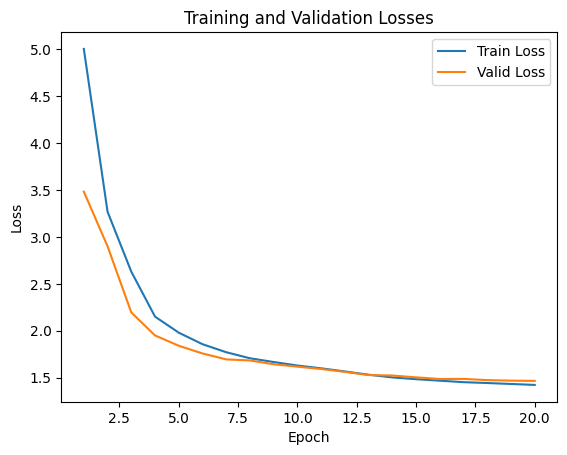

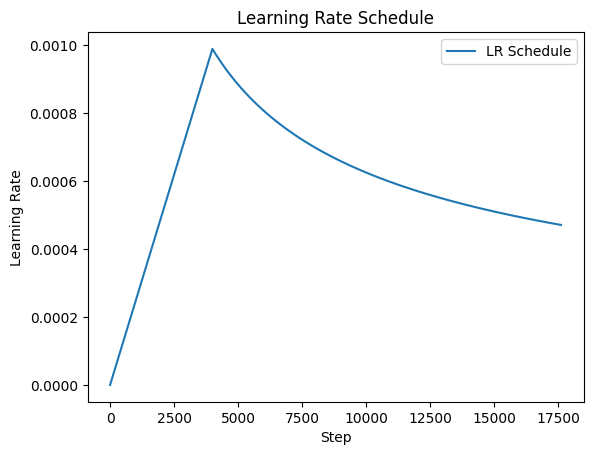

In [35]:
plt.figure()
plt.plot(range(1, num_epochs + 1), epoch_train_losses, label="Train Loss")
plt.plot(range(1, num_epochs + 1), epoch_valid_losses, label="Valid Loss")
plt.title("Training and Validation Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig(FIGURES / "epochs_train_dev_loss.png")
plt.show()
plt.close()

plt.figure()
plt.plot(range(1, len(lr_schedule) + 1), lr_schedule, label="LR Schedule")
plt.title("Learning Rate Schedule")
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.legend()
plt.savefig(FIGURES / "learning_rate_schedule.png")
plt.show()
plt.close()

### Sample outputs

In [40]:
import json
import random
import re
from pathlib import Path

# Token IDs already used by your tokenizer/model.
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3

MAX_OUTPUT_TOKENS = 64
NUM_SAMPLES = 5

device = next(model.parameters()).device
model.eval()


def raw_greedy_inference(source_text, max_tokens=64):
    """Generate raw model output without using decode.py."""

    source_ids = sp.encode(source_text) + [EOS_ID]

    source = torch.tensor(
        [source_ids],
        dtype=torch.long,
        device=device,
    )

    with torch.no_grad():
        source_mask = (
            (source != PAD_ID)
            .unsqueeze(1)
            .unsqueeze(1)
        )

        encoder_output = model.encode(
            source,
            source_mask,
        )

        generated = torch.tensor(
            [[BOS_ID]],
            dtype=torch.long,
            device=device,
        )

        for _ in range(max_tokens):
            target_length = generated.size(1)

            target_mask = torch.tril(
                torch.ones(
                    (
                        1,
                        1,
                        target_length,
                        target_length,
                    ),
                    dtype=torch.bool,
                    device=device,
                )
            )

            decoder_output = model.decode(
                generated,
                encoder_output,
                source_mask,
                target_mask,
            )

            logits = model.projection(
                decoder_output[:, -1:, :]
            )

            next_token = logits[:, -1, :].argmax(
                dim=-1
            ).item()

            generated = torch.cat(
                [
                    generated,
                    torch.tensor(
                        [[next_token]],
                        dtype=torch.long,
                        device=device,
                    ),
                ],
                dim=1,
            )

            if next_token == EOS_ID:
                break

    output_ids = generated[0].tolist()[1:]

    if EOS_ID in output_ids:
        output_ids = output_ids[:output_ids.index(EOS_ID)]

    output_text = sp.decode(output_ids).strip()

    return output_ids, output_text


def parse_raw_prediction(prediction_text):
    """
    Convert model output such as:

        select count <c3> where <c1> = kim

    into WikiSQL format:

        {
            "sel": 3,
            "agg": 3,
            "conds": [[1, 0, "kim"]]
        }
    """

    text = " ".join(prediction_text.lower().strip().split())

    select_match = re.fullmatch(
        r"select\s+"
        r"(?:(max|min|count|sum|avg)\s+)?"
        r"<c(\d+)>"
        r"(.*)",
        text,
    )

    if select_match is None:
        raise ValueError(
            f"Could not parse SELECT clause: {prediction_text!r}"
        )

    aggregate_text = select_match.group(1)
    selected_column = int(select_match.group(2))
    remaining_text = select_match.group(3).strip()

    if aggregate_text is None:
        aggregate = 0
    else:
        aggregate = AGG_OPS.index(aggregate_text.upper())

    conditions = []

    if remaining_text:
        if not remaining_text.startswith("where "):
            raise ValueError(
                f"Invalid WHERE clause: {prediction_text!r}"
            )

        condition_matches = re.finditer(
            r"(?:where|and)\s+"
            r"<c(?P<column>\d+)>\s+"
            r"(?P<operator>=|>|<)\s+"
            r"(?P<value>.*?)"
            r"(?=(?:\s+and\s+<c\d+>\s+(?:=|>|<)\s+)|$)",
            remaining_text,
        )

        condition_matches = list(condition_matches)

        if not condition_matches:
            raise ValueError(
                f"Could not parse conditions: {prediction_text!r}"
            )

        reconstructed = "".join(
            match.group(0)
            for match in condition_matches
        )

        if reconstructed != remaining_text:
            raise ValueError(
                f"Invalid condition format: {prediction_text!r}"
            )

        for match in condition_matches:
            column = int(match.group("column"))
            operator = COND_OPS.index(match.group("operator"))
            value = match.group("value").strip()

            if not value:
                raise ValueError(
                    f"Empty condition value: {prediction_text!r}"
                )

            conditions.append(
                [column, operator, value]
            )

    return {
        "sel": selected_column,
        "agg": aggregate,
        "conds": conditions,
    }


# Create the output directory and prediction file.
prediction_file = Path("results/test_predictions.jsonl")
prediction_file.parent.mkdir(
    parents=True,
    exist_ok=True,
)

successful_predictions = 0
parse_failures = 0
raw_outputs = []

# Run inference over the complete test set.
with prediction_file.open("w", encoding="utf-8") as output_file:
    for index, example in enumerate(test_examples):
        table = test_tables[example["table_id"]]
        header = table["header"]

        source_text = encode_source(
            example["question"],
            header,
        )

        output_ids, output_text = raw_greedy_inference(
            source_text,
            max_tokens=MAX_OUTPUT_TOKENS,
        )

        raw_outputs.append(
            {
                "example": example,
                "header": header,
                "source_text": source_text,
                "output_ids": output_ids,
                "output_text": output_text,
            }
        )

        try:
            predicted_query = parse_raw_prediction(output_text)

            output_file.write(
                json.dumps(
                    {"query": predicted_query},
                    ensure_ascii=False,
                )
                + "\n"
            )

            successful_predictions += 1

        except ValueError:
            output_file.write(
                json.dumps(
                    {"error": "parse"}
                )
                + "\n"
            )

            parse_failures += 1

        if (index + 1) % 100 == 0:
            print(
                f"Processed {index + 1}/{len(test_examples)} "
                f"test examples"
            )

print("=" * 100)
print("Prediction file created")
print("=" * 100)
print(f"Path: {prediction_file.resolve()}")
print(f"Total examples: {len(test_examples)}")
print(f"Successful predictions: {successful_predictions}")
print(f"Parse failures: {parse_failures}")


# Display a few raw input/output examples.
random.seed(42)

sample_indices = random.sample(
    range(len(raw_outputs)),
    min(NUM_SAMPLES, len(raw_outputs)),
)

for sample_number, sample_index in enumerate(
    sample_indices,
    start=1,
):
    sample = raw_outputs[sample_index]
    example = sample["example"]

    print("\n" + "=" * 100)
    print(f"TEST SAMPLE {sample_number}")
    print("=" * 100)

    print("\nRAW INPUT TEXT:")
    print(sample["source_text"])

    print("\nINPUT TOKEN IDS:")
    print(sp.encode(sample["source_text"]))

    print("\nGOLD TARGET:")
    print(example["sql"])

    print("\nRAW MODEL OUTPUT TOKEN IDS:")
    print(sample["output_ids"])

    print("\nRAW MODEL OUTPUT TEXT:")
    print(sample["output_text"])

Processed 100/15878 test examples
Processed 200/15878 test examples
Processed 300/15878 test examples
Processed 400/15878 test examples
Processed 500/15878 test examples
Processed 600/15878 test examples
Processed 700/15878 test examples
Processed 800/15878 test examples
Processed 900/15878 test examples
Processed 1000/15878 test examples
Processed 1100/15878 test examples
Processed 1200/15878 test examples
Processed 1300/15878 test examples
Processed 1400/15878 test examples
Processed 1500/15878 test examples
Processed 1600/15878 test examples
Processed 1700/15878 test examples
Processed 1800/15878 test examples
Processed 1900/15878 test examples
Processed 2000/15878 test examples
Processed 2100/15878 test examples
Processed 2200/15878 test examples
Processed 2300/15878 test examples
Processed 2400/15878 test examples
Processed 2500/15878 test examples
Processed 2600/15878 test examples
Processed 2700/15878 test examples
Processed 2800/15878 test examples
Processed 2900/15878 test exa

## Using WikiSQL Evaluate function

In [49]:
import json
import subprocess
import sys
from pathlib import Path

# Repository root.
WIKISQL_DIR = Path("WikiSQL").resolve()

SOURCE_FILE = (WIKISQL_DIR / "data" / "test.jsonl").resolve()
DB_FILE = (WIKISQL_DIR / "data" / "test.db").resolve()
EVALUATOR_FILE = (WIKISQL_DIR / "evaluate.py").resolve()

PREDICTION_FILE = (
    Path("results") / "test_predictions.jsonl"
).resolve()

for file_path in [
    SOURCE_FILE,
    DB_FILE,
    EVALUATOR_FILE,
    PREDICTION_FILE,
]:
    if not file_path.exists():
        raise FileNotFoundError(
            f"File not found:\n{file_path}"
        )

print("WikiSQL directory:", WIKISQL_DIR)
print("Evaluator:", EVALUATOR_FILE)
print("Source file:", SOURCE_FILE)
print("Database:", DB_FILE)
print("Predictions:", PREDICTION_FILE)

result = subprocess.run(
    [
        sys.executable,
        str(EVALUATOR_FILE),
        str(SOURCE_FILE),
        str(DB_FILE),
        str(PREDICTION_FILE),
    ],
    capture_output=True,
    text=True,
    cwd=str(WIKISQL_DIR),
)

print(result.stdout)

if result.returncode != 0:
    print("Evaluator error:")
    print(result.stderr)
    raise RuntimeError(
        "Official WikiSQL evaluation failed."
    )

WikiSQL directory: /content/WikiSQL
Evaluator: /content/WikiSQL/evaluate.py
Source file: /content/WikiSQL/data/test.jsonl
Database: /content/WikiSQL/data/test.db
Predictions: /content/results/test_predictions.jsonl
{
  "ex_accuracy": 0.5024562287441743,
  "lf_accuracy": 0.46668346139312256
}



## Load Model State

In [ ]:
from google.colab import files
from pathlib import Path
import shutil

checkpoint_dir = Path("/content/artifacts/checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

uploaded_files = files.upload()

for filename in uploaded_files:
    source_path = Path(filename)

    shutil.move(
        str(source_path),
        str(destination_path),
    )

    print(f"Uploaded: {destination_path}")

print("\nCheckpoint directory contents:")
for path in checkpoint_dir.iterdir():
    print(path)

In [ ]:
CHECKPOINT_PATH = Path("artifacts/checkpoints/best.pt")
TOKENIZER_PATH = Path("artifacts/tokenizer/sql_sp.model")

# Select CPU or GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Load SentencePiece tokenizer
sp = spm.SentencePieceProcessor(
    model_file=str(TOKENIZER_PATH)
)

# Build the model with the same configuration used during training
model = build_transformer(
    vocab_size=sp.get_piece_size(),
    max_len=512,
    d_model=256,
    h=4,
    N=3,
    d_ff=1024,
    dropout=0.1,
    device=device,
)

# Load checkpoint weights
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
)

# Support both a raw state_dict and a checkpoint dictionary.
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

# Inference mode
model.eval()

print("Model loaded successfully")
print("Device:", device)
print("Vocabulary size:", sp.get_piece_size())
print(
    "Trainable parameters:",
    sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    ),
)